# Zero-Shot Object Detection with OwlViT

This notebook demonstrates zero-shot object detection with **OwlViT (Vision Transformer for Open-World Localization)** using natural-language prompts.

Unlike a conventional object detector with a fixed set of predefined classes, OwlViT can evaluate text queries against image regions without task-specific fine-tuning. The same detection model can therefore be queried with different object concepts at inference time.

**Key Components:**

1. **Zero-Shot Detection:** Uses natural-language prompts to define the objects of interest at inference time.
2. **Text-Image Grounding:** Processes the image and text queries jointly and assigns candidate regions to the requested concepts.
3. **Bounding Box Extraction:** Converts model outputs into image-space bounding boxes and confidence scores.
4. **Threshold Analysis:** Examines how the confidence threshold affects the number of returned detections.
5. **Quantitative Inspection:** Reports detection counts, confidence statistics, and bounding-box geometry rather than relying only on visualization.
6. **Visualization:** Draws the detected regions and associated confidence scores directly on the input image.

**Goal:**
To demonstrate a complete zero-shot detection pipeline from natural-language query → multimodal inference → post-processing → quantitative inspection → visual grounding.


In [ ]:
!pip install -q --upgrade transformers requests opencv-python

## 1. Imports & Reproducibility

The experiment configuration is kept explicit so that the model, image source, prompts, and detection threshold can be reproduced.

A fixed random seed is used for deterministic components where applicable. The inference itself does not require gradient computation because the pretrained model is evaluated without parameter updates.


In [ ]:
import random
import time

import cv2
import torch
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from PIL import Image
from transformers import OwlViTProcessor, OwlViTForObjectDetection

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


## 2. Display Backend

The visualization code supports both Google Colab and standard local Python environments.

Colab provides `cv2_imshow`, while local environments use Matplotlib for displaying the final OpenCV-rendered image.


In [ ]:
try:
    from google.colab.patches import cv2_imshow
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running in Google Colab:", IN_COLAB)


## 3. Loading the Pretrained OwlViT Model

The pretrained `google/owlvit-base-patch32` checkpoint is loaded for inference.

OwlViT uses a Vision Transformer image encoder together with a text encoder, allowing the detector to evaluate image regions against arbitrary textual queries.


In [ ]:
model_id = "google/owlvit-base-patch32"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Loading {model_id}...")

processor = OwlViTProcessor.from_pretrained(model_id)
model = OwlViTForObjectDetection.from_pretrained(model_id)
model = model.to(device)
model.eval()

total_parameters = sum(parameter.numel() for parameter in model.parameters())

print("Model loaded successfully.")
print("Device:", device)
print("Total parameters:", f"{total_parameters:,}")


## 4. Loading and Inspecting the Input Image

The image is downloaded from the COCO validation dataset and converted to RGB before inference.

Basic image properties are inspected explicitly because bounding boxes returned by the detector are ultimately interpreted in the coordinate system of the original image.


In [ ]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"

print(f"Downloading image from: {url}")

response = requests.get(url, stream=True, timeout=30)
response.raise_for_status()

image = Image.open(response.raw).convert("RGB")

print(f"Image loaded: size={image.size}")
print(f"Width: {image.width}px")
print(f"Height: {image.height}px")
print(f"Aspect ratio: {image.width / image.height:.3f}")


## 5. Natural-Language Detection Queries

The detection vocabulary is defined entirely by text prompts.

The prompts are intentionally written as natural-language descriptions rather than numeric class IDs. This is the central zero-shot property being demonstrated: the detection task is specified at inference time through language.


In [ ]:
text_labels = [[
    "a photo of a cat",
    "a photo of a dog",
    "a remote control"
]]

print("Detection queries:")
for label in text_labels[0]:
    print(f" - {label}")


## 6. Multimodal Input Preparation

The processor converts both the image and text queries into the tensor representation expected by OwlViT.

The resulting tensors are moved to the selected device before inference.


In [ ]:
inputs = processor(
    text=text_labels,
    images=image,
    return_tensors="pt"
)

inputs = {
    key: value.to(device) if isinstance(value, torch.Tensor) else value
    for key, value in inputs.items()
}

print("Prepared model inputs:")
for key, value in inputs.items():
    if isinstance(value, torch.Tensor):
        print(f"{key}: {tuple(value.shape)}")
    else:
        print(f"{key}: {type(value).__name__}")


## 7. Zero-Shot Object Detection

The model is executed in inference mode with gradients disabled.

Disabling gradient computation reduces memory usage and avoids unnecessary autograd overhead because no model parameters are being updated.


In [ ]:
print("Running zero-shot detection...")

start_time = time.perf_counter()

with torch.inference_mode():
    outputs = model(**inputs)

inference_time = time.perf_counter() - start_time

print(f"Inference completed in {inference_time:.4f} seconds")


## 8. Post-Processing and Bounding Box Extraction

The raw model outputs are converted into image-space detections using the processor's grounded object-detection post-processing function.

A confidence threshold of `0.1` is used for the initial inspection. This relatively permissive threshold makes it possible to inspect candidate detections before applying stricter filtering.


In [ ]:
threshold = 0.1
target_sizes = torch.tensor(
    [(image.height, image.width)],
    device=device
)

results = processor.post_process_grounded_object_detection(
    outputs=outputs,
    target_sizes=target_sizes,
    threshold=threshold,
    text_labels=text_labels
)[0]

boxes = results["boxes"].detach().cpu()
scores = results["scores"].detach().cpu()
labels = results["text_labels"]

print(f"Detected {len(boxes)} objects at threshold={threshold}:")
for box, score, label in zip(boxes, scores, labels):
    box_coords = [round(value, 2) for value in box.tolist()]
    print(
        f"- {label:<20} | "
        f"Confidence: {score.item():.3f} | "
        f"BBox: {box_coords}"
    )


## 9. Quantitative Detection Analysis

A detection is more informative when its numerical properties can be inspected independently of the visualization.

For each returned region, the bounding-box width, height, area, and normalized image coverage are calculated. These measurements provide basic geometric information about what the model is grounding in the image.


In [ ]:
detection_rows = []

image_area = image.width * image.height

for box, score, label in zip(boxes, scores, labels):
    x_min, y_min, x_max, y_max = box.tolist()
    width = max(x_max - x_min, 0)
    height = max(y_max - y_min, 0)
    area = width * height

    detection_rows.append({
        "label": label,
        "confidence": float(score),
        "x_min": round(x_min, 2),
        "y_min": round(y_min, 2),
        "x_max": round(x_max, 2),
        "y_max": round(y_max, 2),
        "width": round(width, 2),
        "height": round(height, 2),
        "area_pixels": round(area, 2),
        "image_area_ratio": area / image_area
    })

detection_df = pd.DataFrame(detection_rows)

if len(detection_df) > 0:
    display(detection_df)
else:
    print("No detections passed the selected threshold.")


## 10. Confidence Threshold Sensitivity

The confidence threshold directly controls which candidate detections are returned.

Instead of treating one threshold as universally correct, several thresholds are evaluated. This provides a simple sensitivity analysis showing how the number of retained detections changes as the detector becomes more selective.


In [ ]:
thresholds = [0.05, 0.10, 0.20, 0.30, 0.50]

threshold_rows = []

for current_threshold in thresholds:
    threshold_result = processor.post_process_grounded_object_detection(
        outputs=outputs,
        target_sizes=target_sizes,
        threshold=current_threshold,
        text_labels=text_labels
    )[0]

    threshold_rows.append({
        "threshold": current_threshold,
        "detections": len(threshold_result["boxes"]),
        "mean_confidence": (
            float(threshold_result["scores"].mean())
            if len(threshold_result["scores"]) > 0
            else np.nan
        )
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)


## 11. Visualizing Grounded Detections

The final detections are rendered on the original image.

Each bounding box represents a region that the model associated with one of the supplied text queries. The label and confidence score are displayed together so that the visual grounding can be interpreted alongside the numerical output.


In [ ]:
image_np = np.array(image)
image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

for box, score, label in zip(boxes, scores, labels):
    x_min, y_min, x_max, y_max = [int(value) for value in box.tolist()]

    cv2.rectangle(
        image_bgr,
        (x_min, y_min),
        (x_max, y_max),
        color=(0, 0, 255),
        thickness=2
    )

    text = f"{label}: {score.item():.2f}"
    (text_width, text_height), _ = cv2.getTextSize(
        text,
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        2
    )

    y_text = max(y_min - text_height - 5, 0)

    cv2.rectangle(
        image_bgr,
        (x_min, y_text),
        (x_min + text_width, y_min),
        (0, 0, 255),
        -1
    )

    cv2.putText(
        image_bgr,
        text,
        (x_min, max(y_min - 5, text_height)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2
    )

if IN_COLAB:
    cv2_imshow(image_bgr)
else:
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("OwlViT Zero-Shot Detection")
    plt.show()


## 12. Per-Query Detection Summary

The detections are grouped by text query to show which concepts were grounded in the image and how confidently they were detected.

This is useful for zero-shot detection because the model is not restricted to a fixed class vocabulary; the query itself determines which concepts are evaluated.


In [ ]:
if len(detection_df) > 0:
    query_summary = (
        detection_df.groupby("label")
        .agg(
            detections=("label", "size"),
            max_confidence=("confidence", "max"),
            mean_confidence=("confidence", "mean")
        )
        .reset_index()
        .sort_values("max_confidence", ascending=False)
    )

    display(query_summary)
else:
    print("No detections available for query-level analysis.")


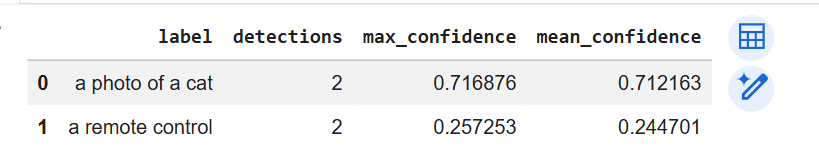

## 13. Research Interpretation

TInterpretation of OwlViT Zero-Shot Detection Results

The results show that OwlViT successfully detected both queried concepts, “a photo of a cat” and “a remote control,” with 2 detections each. The cat query achieved a much higher maximum confidence of 0.717 and mean confidence of 0.712, indicating that the model was considerably more confident in identifying the cat. In contrast, the remote-control query had a maximum confidence of only 0.257 and mean confidence of 0.245, suggesting that the model was much less certain about those detections.

Overall, the results demonstrate OwlViT’s zero-shot capability, as it can detect objects based on natural-language prompts without task-specific retraining. However, the relatively low confidence for the remote-control query indicates that prompt selection and confidence thresholding can strongly influence zero-shot detection performance. Since this experiment does not use ground-truth bounding-box evaluation, these confidence scores should not be interpreted as formal detection accuracy.

# Limitations

There are important limitations. This notebook does not calculate a standard object-detection metric such as mAP because no ground-truth bounding-box annotations are evaluated against the model predictions in this experiment. Confidence scores alone should therefore not be interpreted as quantitative detection accuracy.

A stronger evaluation would use an annotated dataset and calculate metrics such as mAP, AP50, AP75, precision, and recall across multiple images and object categories. Prompt variations could also be evaluated systematically to study the effect of language formulation on zero-shot grounding.

The current experiment intentionally remains focused:

`image + text queries → multimodal inference → thresholded detections → quantitative inspection → visual grounding`

This demonstrates the core mechanics of open-vocabulary object detection while leaving room for a later controlled benchmark experiment.
